<a href="https://colab.research.google.com/github/legong-beep/MPM_204_Gong/blob/main/labs/06_mixed__effects_models_pk_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
install.packages(c('lme4', 'GGally', 'reshape2'))

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘rbibutils’, ‘patchwork’, ‘Rdpack’, ‘minqa’, ‘nloptr’, ‘reformulas’, ‘RcppEigen’, ‘ggstats’, ‘plyr’




In [2]:
install.packages("sjPlot")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘effectsize’, ‘bayestestR’, ‘datawizard’, ‘ggeffects’, ‘insight’, ‘parameters’, ‘performance’, ‘sjlabelled’, ‘sjmisc’, ‘sjstats’




In [3]:
require(ggplot2)
require(GGally)
require(reshape2)
require(lme4)
require(compiler)
require(parallel)
require(boot)
require(lattice)
require(sjPlot)

Loading required package: ggplot2

Loading required package: GGally

Loading required package: reshape2

Loading required package: lme4

Loading required package: Matrix

Loading required package: compiler

Loading required package: parallel

Loading required package: boot

Loading required package: lattice


Attaching package: ‘lattice’


The following object is masked from ‘package:boot’:

    melanoma


Loading required package: sjPlot


Attaching package: ‘sjPlot’


The following object is masked from ‘package:ggplot2’:

    set_theme




## Data description

* In this example, we will explore data about cancer using a simulated dataset.  
* A variety of outcomes were collected on patients, who are nested within `doctors`, who are, in turn, nested within `hospitals`.
* There are also a few doctor-level variables, such as experience, that we will use in our example

In [5]:
hdp  = read.csv("/content/hdp.csv")
hdp <- within(hdp, {
  DID <- factor(DID)
  HID <- factor(HID)
  CancerStage <- factor(CancerStage)
})
head(hdp, 50)

,X,tumorsize,co2,pain,wound,mobility,ntumors,nmorphine,remission,lungcapacity,⋯,RBC,BMI,IL6,CRP,DID,Experience,School,Lawsuits,HID,Medicaid
,<int>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>,<int>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<int>,<chr>,<int>,<fct>,<dbl>
1,1,67.98120,1.534333,4,4,2,0,0,0,0.8010882,⋯,4.868416,24.14424,3.6989811,8.0864168,1,25,average,3,1,0.6058667
2,2,64.70246,1.676132,2,3,2,0,0,0,0.3264440,⋯,4.679052,29.40516,2.6274806,0.8034876,1,25,average,3,1,0.6058667
3,3,51.56700,1.533445,6,3,2,0,0,0,0.5650309,⋯,5.005862,29.48259,13.8961528,4.0341565,1,25,average,3,1,0.6058667
4,4,86.43799,1.453300,3,3,2,0,0,0,0.8484109,⋯,5.265058,21.55726,3.0080334,2.1258629,1,25,average,3,1,0.6058667
5,5,53.40018,1.566348,3,4,2,0,0,0,0.8864910,⋯,4.984259,29.81519,3.8906978,1.3493239,1,25,average,3,1,0.6058667
6,6,51.65727,1.417868,4,5,2,0,0,0,0.7010307,⋯,5.199714,27.10252,1.4182187,2.1946941,1,25,average,3,1,0.6058667
7,7,78.91707,1.706632,3,4,2,0,0,0,0.8908539,⋯,4.869905,21.11907,2.2932198,8.6079565,1,25,average,3,1,0.6058667
8,8,69.83325,1.528726,3,3,3,0,0,0,0.6608795,⋯,4.647919,42.47545,4.5756204,0.8383885,1,25,average,3,1,0.6058667
9,9,62.85259,1.542961,4,4,3,2,0,0,0.9088714,⋯,4.827062,18.68505,8.0302027,7.2261278,1,25,average,3,1,0.6058667


In [6]:
colnames(hdp)

[1] "X"            "tumorsize"    "co2"          "pain"         "wound"       
 [6] "mobility"     "ntumors"      "nmorphine"    "remission"    "lungcapacity"
[11] "Age"          "Married"      "FamilyHx"     "SmokingHx"    "Sex"         
[16] "CancerStage"  "LengthofStay" "WBC"          "RBC"          "BMI"         
[21] "IL6"          "CRP"          "DID"          "Experience"   "School"      
[26] "Lawsuits"     "HID"          "Medicaid"

### Data exploration

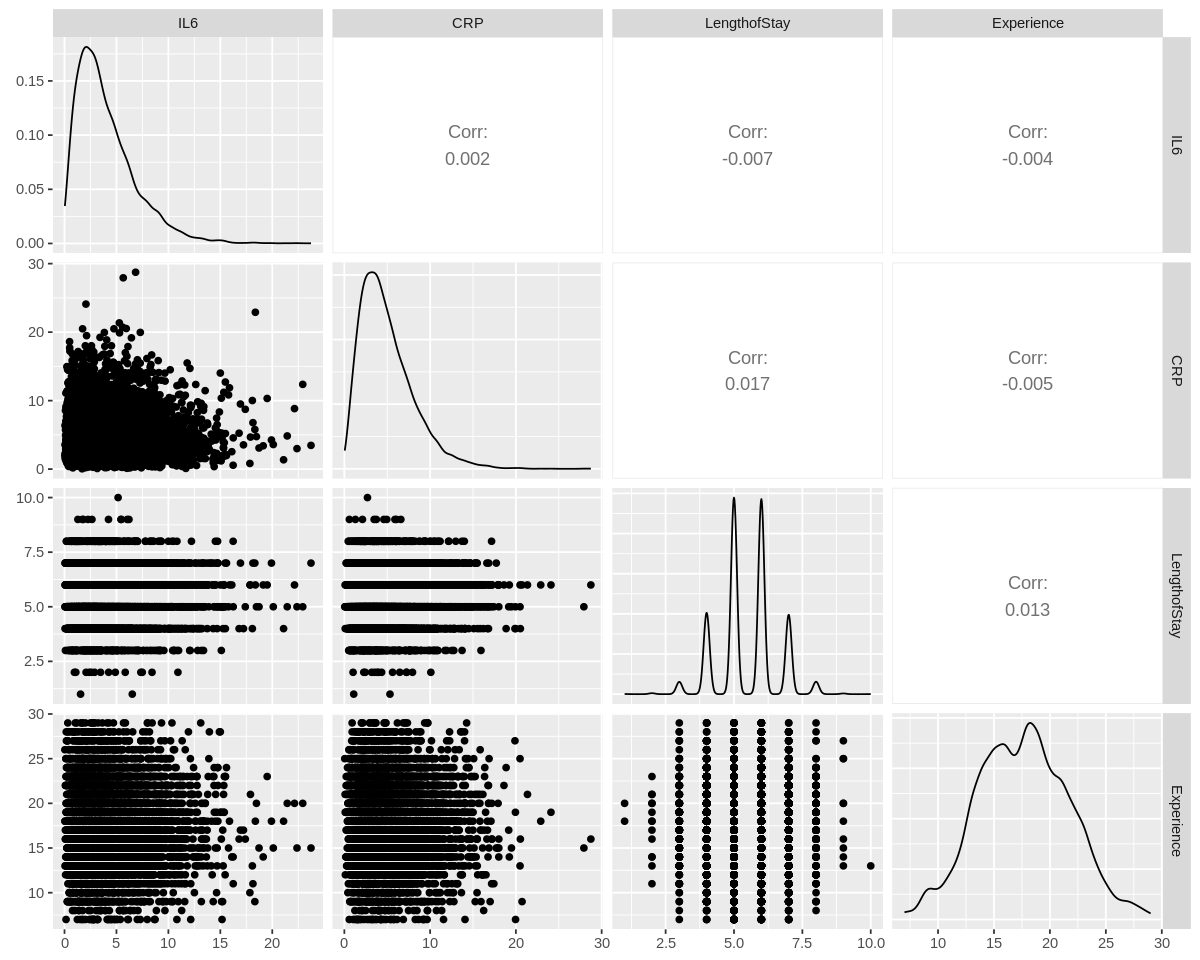

In [7]:
options(repr.plot.width = 10, repr.plot.height = 8)
ggpairs(hdp[, c("IL6", "CRP", "LengthofStay", "Experience")])

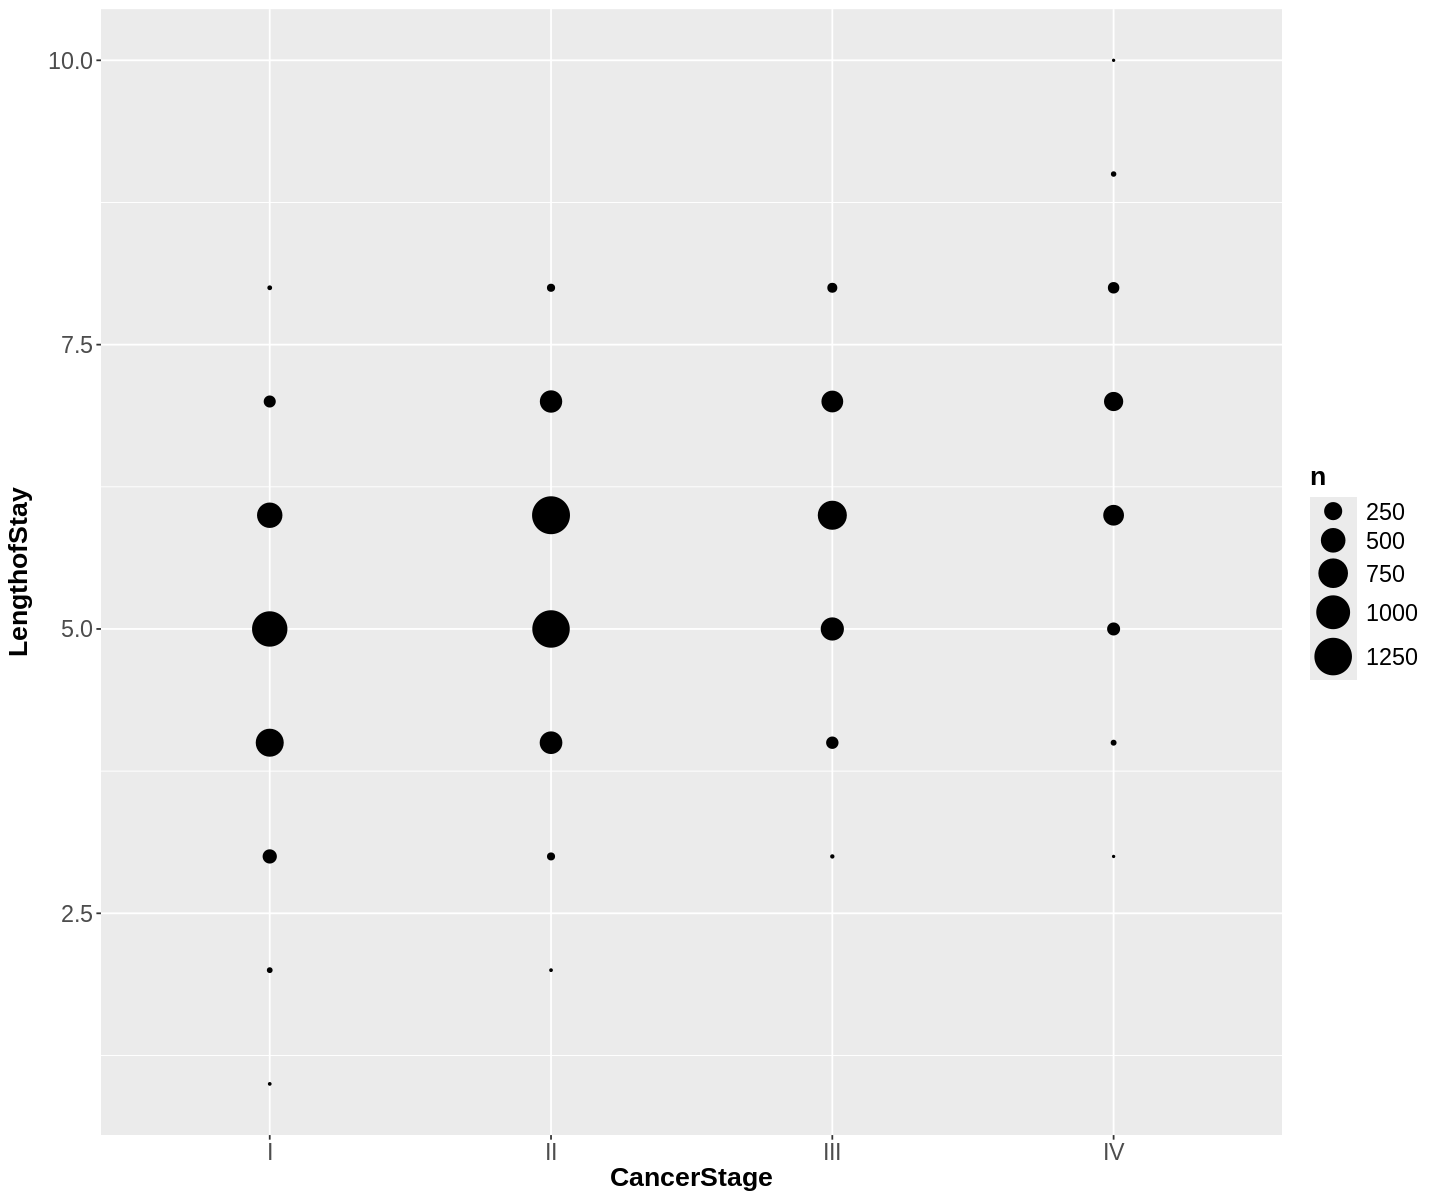

In [8]:
options(repr.plot.width = 12, repr.plot.height = 10)
ggplot(hdp, aes(x = CancerStage, y = LengthofStay)) +
  stat_sum(aes(size = after_stat(n), group = 1)) +
  scale_size_area(max_size=10) +
  theme(axis.text = element_text(size = 14),
        axis.title = element_text(size = 16, face = "bold"),
        legend.title = element_text(size = 16, face = "bold"),
        legend.text = element_text(size = 14))

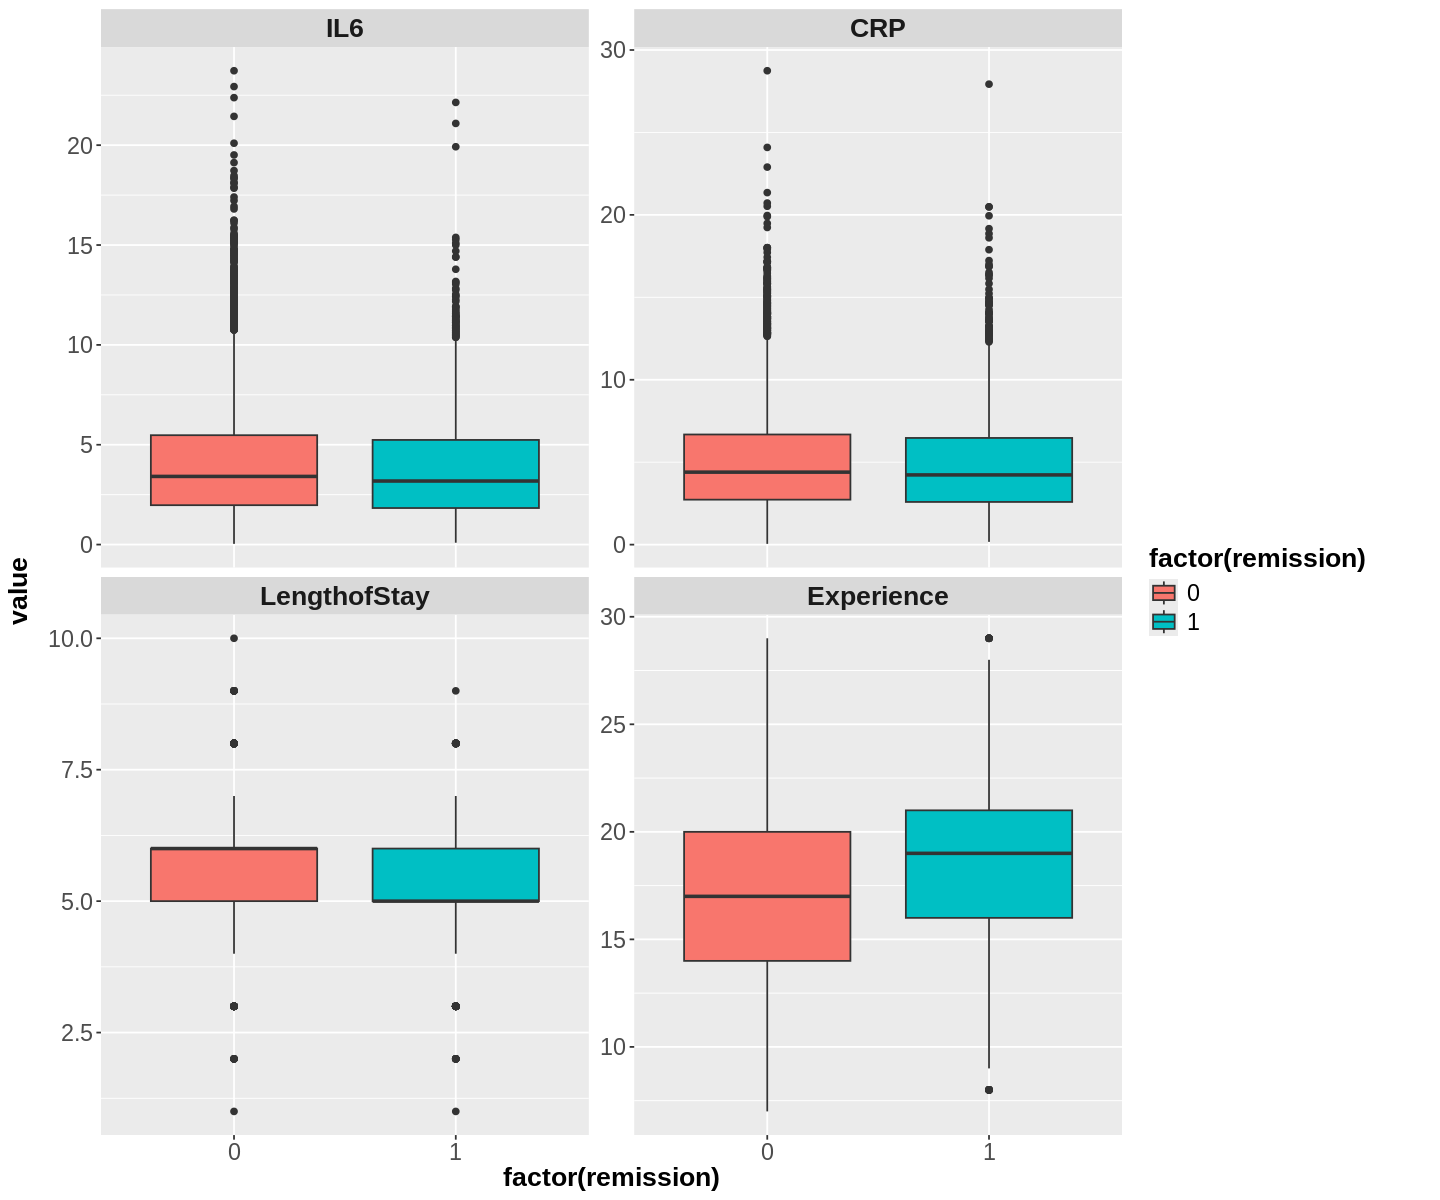

In [9]:
tmp <- melt(hdp[, c("remission", "IL6", "CRP", "LengthofStay", "Experience")],
  id.vars="remission")
options(repr.plot.width = 12, repr.plot.height = 10)
ggplot(tmp, aes(factor(remission), y = value, fill=factor(remission))) +
  geom_boxplot() +
  facet_wrap(~variable, scales="free_y")+
  theme(axis.text = element_text(size = 14),
        axis.title = element_text(size = 16, face = "bold"),
        legend.title = element_text(size = 16, face = "bold"),
        legend.text = element_text(size = 14),
        strip.text = element_text(size = 16, face = "bold"))

## Mixed effects logistic regression

`glmer` command
* `Il6`, `CRP`, and `LengthofStay` as patient level continuous predictors
* `CancerStage` patient level categorical predictor
* `Experience` as doctor level continuous predictor
* `DID` as doctor ID as random intercept


`glmerControl(optimizer = "bobyqa")` see the argument `glmerControl`  
It allows us to use a different optimizer...     
You may get similar results with other optimers but convergence process will not result in warnings (prefered).   

In [10]:
print(?glmerControl)

In [11]:
# estimate the model and store results in m
m <- glmer(remission ~ IL6 + CRP + CancerStage + LengthofStay + Experience +
    (1 | DID), data = hdp, family = binomial, control = glmerControl(optimizer = "bobyqa"),
    nAGQ = 10)

# print the mod results without correlations among fixed effects
print(m, corr = FALSE)

Generalized linear mixed model fit by maximum likelihood (Adaptive
  Gauss-Hermite Quadrature, nAGQ = 10) [glmerMod]
 Family: binomial  ( logit )
Formula: remission ~ IL6 + CRP + CancerStage + LengthofStay + Experience +  
    (1 | DID)
   Data: hdp
      AIC       BIC    logLik -2*log(L)  df.resid 
 7397.276  7460.733 -3689.638  7379.276      8516 
Random effects:
 Groups Name        Std.Dev.
 DID    (Intercept) 2.015   
Number of obs: 8525, groups:  DID, 407
Fixed Effects:
   (Intercept)             IL6             CRP   CancerStageII  CancerStageIII  
      -2.05272        -0.05677        -0.02148        -0.41393        -1.00347  
 CancerStageIV    LengthofStay      Experience  
      -2.33703        -0.12118         0.12009  


In [ ]:
#407 good candidate for

In [16]:
m_glm <- glm(remission ~ IL6 + CRP + CancerStage + LengthofStay + Experience,
data = hdp, family = binomial)
m_glm


Call:  glm(formula = remission ~ IL6 + CRP + CancerStage + LengthofStay + 
    Experience, family = binomial, data = hdp)

Coefficients:
   (Intercept)             IL6             CRP   CancerStageII  CancerStageIII  
      -1.30970        -0.03849        -0.01725        -0.27943        -0.62267  
 CancerStageIV    LengthofStay      Experience  
      -1.59433        -0.08900         0.08440  

Degrees of Freedom: 8524 Total (i.e. Null);  8517 Residual
Null Deviance:	    10350 
Residual Deviance: 9815 	AIC: 9831

#### Random effects:
* Estimated variability in the intercept on the logit scale


#### Fixed effects
* represent coefficients (logit scale)

#### Estimating Standard Errors
* In GLMs SEs are estimated by inverting the observed information matrix (negative second derivative matrix)
* In GLMMs it is done through approximation

#### SEs and CIs can be roughly estimated as follows

In [17]:
round(vcov(m), digits = 4)

8 x 8 Matrix of class "dsyMatrix"
               (Intercept)    IL6    CRP CancerStageII CancerStageIII
(Intercept)         0.2825 -5e-04 -5e-04        0.0006         0.0030
IL6                -0.0005  1e-04  0e+00        0.0000         0.0000
CRP                -0.0005  0e+00  1e-04        0.0000         0.0000
CancerStageII       0.0006  0e+00  0e+00        0.0057         0.0037
CancerStageIII      0.0030  0e+00  0e+00        0.0037         0.0097
CancerStageIV       0.0057  1e-04  0e+00        0.0040         0.0050
LengthofStay       -0.0053  0e+00  0e+00       -0.0007        -0.0011
Experience         -0.0134  0e+00  0e+00        0.0000         0.0000
               CancerStageIV LengthofStay Experience
(Intercept)           0.0057      -0.0053    -0.0134
IL6                   0.0001       0.0000     0.0000
CRP                   0.0000       0.0000     0.0000
CancerStageII         0.0040      -0.0007     0.0000
CancerStageIII        0.0050      -0.0011     0.0000
CancerStageIV     

In [18]:
knitr::kable(sqrt(diag(vcov(m))))



|               |         x|
|:--------------|---------:|
|(Intercept)    | 0.5314926|
|IL6            | 0.0115184|
|CRP            | 0.0102184|
|CancerStageII  | 0.0757640|
|CancerStageIII | 0.0982833|
|CancerStageIV  | 0.1580581|
|LengthofStay   | 0.0336336|
|Experience     | 0.0274537|

In [19]:
se <- sqrt(diag(vcov(m)))

In [20]:
?diag

In [21]:
summary(m)

Generalized linear mixed model fit by maximum likelihood (Adaptive
  Gauss-Hermite Quadrature, nAGQ = 10) [glmerMod]
 Family: binomial  ( logit )
Formula: remission ~ IL6 + CRP + CancerStage + LengthofStay + Experience +  
    (1 | DID)
   Data: hdp
Control: glmerControl(optimizer = "bobyqa")

      AIC       BIC    logLik -2*log(L)  df.resid 
   7397.3    7460.7   -3689.6    7379.3      8516 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-3.7739 -0.4424 -0.1999  0.3968  7.1030 

Random effects:
 Groups Name        Variance Std.Dev.
 DID    (Intercept) 4.058    2.015   
Number of obs: 8525, groups:  DID, 407

Fixed effects:
               Estimate Std. Error z value Pr(>|z|)    
(Intercept)    -2.05272    0.53149  -3.862 0.000112 ***
IL6            -0.05677    0.01152  -4.929 8.27e-07 ***
CRP            -0.02148    0.01022  -2.102 0.035520 *  
CancerStageII  -0.41393    0.07576  -5.463 4.67e-08 ***
CancerStageIII -1.00347    0.09828 -10.210  < 2e-16 ***
CancerStageIV  -2

In [22]:
knitr::kable(fixef(m))



|               |          x|
|:--------------|----------:|
|(Intercept)    | -2.0527208|
|IL6            | -0.0567719|
|CRP            | -0.0214829|
|CancerStageII  | -0.4139333|
|CancerStageIII | -1.0034668|
|CancerStageIV  | -2.3370317|
|LengthofStay   | -0.1211819|
|Experience     |  0.1200897|

In [23]:
# table of estimates with 95% CI
(tab <- cbind(Est = fixef(m), LL = fixef(m) - 1.96 * se, UL = fixef(m) + 1.96 *
    se))

,Est,LL,UL
(Intercept),-2.05272076,-3.09444629,-1.01099522
IL6,-0.05677188,-0.07934791,-0.03419586
CRP,-0.02148295,-0.04151102,-0.00145488
CancerStageII,-0.41393330,-0.56243065,-0.26543595
CancerStageIII,-1.00346676,-1.19610199,-0.81083153
CancerStageIV,-2.33703172,-2.64682551,-2.02723792
LengthofStay,-0.12118194,-0.18710382,-0.05526005
Experience,0.12008972,0.06628045,0.17389900


In [24]:
exp(tab)

,Est,LL,UL
(Intercept),0.12838512,0.04530009,0.3638567
IL6,0.94480957,0.92371850,0.9663822
CRP,0.97874617,0.95933877,0.9985462
CancerStageII,0.66104504,0.56982234,0.7668716
CancerStageIII,0.36660630,0.30237056,0.4444883
CancerStageIV,0.09661399,0.07087585,0.1316988
LengthofStay,0.88587277,0.82935762,0.9462390
Experience,1.12759802,1.06852634,1.1899354


In [25]:
library(sjPlot)
tab_model(m)

In [26]:
# estimate the model and store results in m
m_v2 <- glmer(remission ~ IL6 + CRP + CancerStage + LengthofStay + Experience +
    (1 | DID), data = hdp, family = binomial)

# print the mod results without correlations among fixed effects
print(m_v2, corr = FALSE)

Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“Model failed to converge with max|grad| = 0.400254 (tol = 0.002, component 1)
  See ?lme4::convergence and ?lme4::troubleshooting.”


Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: binomial  ( logit )
Formula: remission ~ IL6 + CRP + CancerStage + LengthofStay + Experience +  
    (1 | DID)
   Data: hdp
      AIC       BIC    logLik -2*log(L)  df.resid 
 7410.106  7473.563 -3696.053  7392.106      8516 
Random effects:
 Groups Name        Std.Dev.
 DID    (Intercept) 1.973   
Number of obs: 8525, groups:  DID, 407
Fixed Effects:
   (Intercept)             IL6             CRP   CancerStageII  CancerStageIII  
      -2.02910        -0.05581        -0.02041        -0.41395        -1.00027  
 CancerStageIV    LengthofStay      Experience  
      -2.34159        -0.12017         0.11797  
optimizer (Nelder_Mead) convergence code: 0 (OK) ; 0 optimizer warnings; 1 lme4 warnings 


### Multiple random effects
* `glmer`: no need to specify if random effects are nested (required for other commands in R)

In [27]:
m2 <- glmer(remission ~ Age + LengthofStay + FamilyHx + IL6 + CRP +
  CancerStage + Experience + (1 | DID) + (1 | HID),
  data = hdp, control = glmerControl(optimizer = "bobyqa"), family = binomial, nAGQ=1)

In [28]:
summary(m2, corr=FALSE)

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: binomial  ( logit )
Formula: remission ~ Age + LengthofStay + FamilyHx + IL6 + CRP + CancerStage +  
    Experience + (1 | DID) + (1 | HID)
   Data: hdp
Control: glmerControl(optimizer = "bobyqa")

      AIC       BIC    logLik -2*log(L)  df.resid 
   7198.9    7283.5   -3587.5    7174.9      8513 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-4.1298 -0.4243 -0.1886  0.3576  7.6201 

Random effects:
 Groups Name        Variance Std.Dev.
 DID    (Intercept) 3.843    1.960   
 HID    (Intercept) 0.253    0.503   
Number of obs: 8525, groups:  DID, 407; HID, 35

Fixed effects:
                Estimate Std. Error z value Pr(>|z|)    
(Intercept)    -1.624349   0.572651  -2.837  0.00456 ** 
Age            -0.016023   0.005925  -2.704  0.00684 ** 
LengthofStay   -0.041712   0.035596  -1.172  0.24127    
FamilyHxyes    -1.305407   0.093628 -13.942  < 2e-16 ***
IL6            

In [29]:
#another version
m3 <- glmer(remission ~ Age + LengthofStay + FamilyHx + IL6 + CRP +
  CancerStage + Experience + (1 | DID/HID),
  data = hdp, control = glmerControl(optimizer = "bobyqa"), family = binomial, nAGQ=1)

summary(m3, corr = F)

Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“unable to evaluate scaled gradient”
Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“Model failed to converge: degenerate  Hessian with 1 negative eigenvalues
  See ?lme4::convergence and ?lme4::troubleshooting.”


Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: binomial  ( logit )
Formula: remission ~ Age + LengthofStay + FamilyHx + IL6 + CRP + CancerStage +  
    Experience + (1 | DID/HID)
   Data: hdp
Control: glmerControl(optimizer = "bobyqa")

      AIC       BIC    logLik -2*log(L)  df.resid 
   7203.4    7288.0   -3589.7    7179.4      8513 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-4.1464 -0.4225 -0.1878  0.3583  7.8797 

Random effects:
 Groups  Name        Variance Std.Dev.
 HID:DID (Intercept) 1.082    1.040   
 DID     (Intercept) 3.029    1.741   
Number of obs: 8525, groups:  HID:DID, 407; DID, 407

Fixed effects:
                Estimate Std. Error z value Pr(>|z|)    
(Intercept)    -1.636386   0.572998  -2.856  0.00429 ** 
Age            -0.016015   0.005928  -2.701  0.00690 ** 
LengthofStay   -0.041328   0.035617  -1.160  0.24591    
FamilyHxyes    -1.305503   0.093729 -13.928  < 2e-16 ***
IL6            

In [ ]:
#results did not converge; nesting
#not necessary to fit as a nested effect bc...

In [ ]:
#ranef(m2)

A dot plot to visualize the random effects associated with the `DID` (Doctor ID) and `HID` (Hospital ID) grouping variables from the mixed-effects model `m2`.

Each dot represents the estimated random effect for a specific doctor or hospital, and the horizontal lines typically indicate their confidence intervals.

In both dot plots, the y-axis represents the estimated random intercepts for each grouping variable. These values are on the logit scale because the `glmer` model `m2` uses a `binomial` family, which is a logistic regression. A positive value indicates that the group tends to have a higher log-odds of remission compared to the average, while a negative value indicates a lower log-odds.

$DID


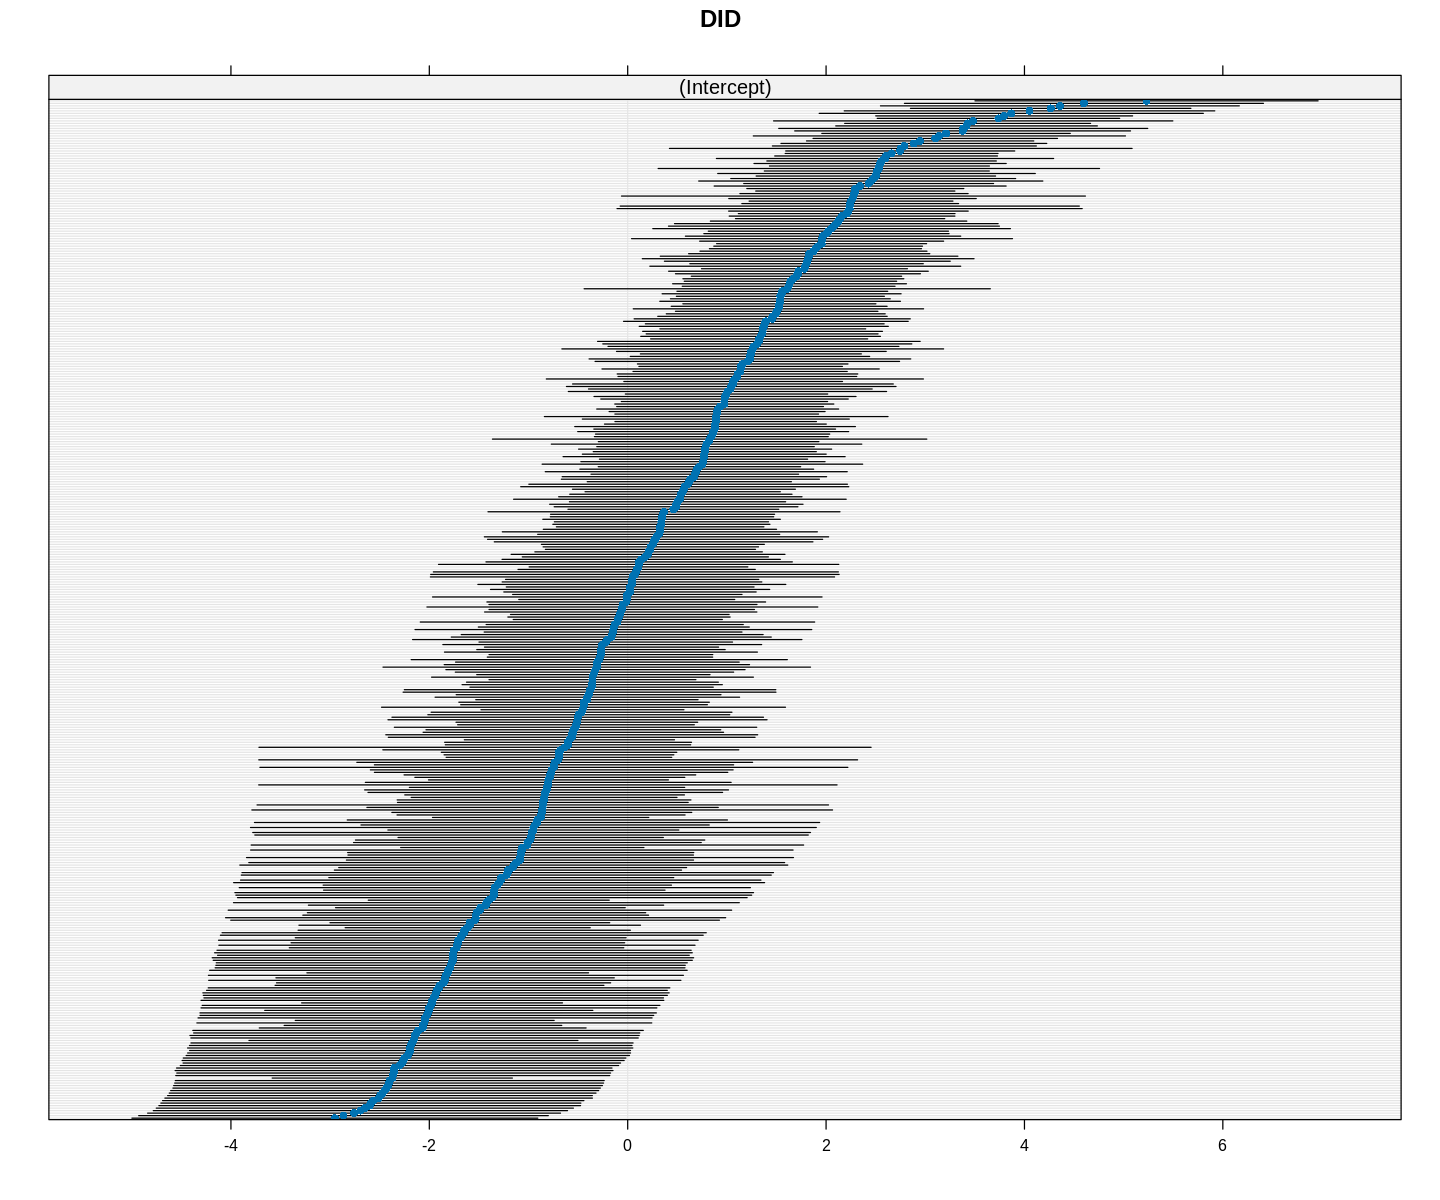

In [30]:
#model random effects
lattice::dotplot(ranef(m2, which = "DID", condVar = TRUE), scales = list(y = list(alternating = 0)))

In [ ]:
#y axis
#intercepts for each of the doctors


In [ ]:
lattice::dotplot(ranef(m2, which = "HID", condVar = TRUE), scales = list(y = list(alternating = 0)))

In [ ]:
plot_models(m2) + theme(axis.text = element_text(size = 14),
                        axis.title = element_text(size = 16, face = "bold"),
                        legend.text = element_text(size = 14),
                        legend.title = element_text(size = 16, face = "bold"))

In [ ]:
tab_model(m2, file = 'model_tabulation.html')

### Interpretation of Random effects
* We talk about them in terms of their variability rather than discussing them individually.

* The significance of random effects in GLMMs can be evaluated using likelihood ratio tests (LRTs) `anova` by comparing models with and without the random effects. The LRT compares the log-likelihood of the full model with the log-likelihood of a reduced model that excludes the random effects. If the LRT is statistically significant, it indicates that the random effects significantly improve the fit of the model.


* `σ2` **(sigma squared)**: This is the estimated variance of the error term (residuals) in the model. It represents the amount of variation in the outcome variable that is not explained by the model's fixed and random effects.  

* In GLMMs, the random effects are assumed to be normally distributed with mean zero and variance `τ`, and they account for the clustering or dependency of the data.

* `τ00 DID`: This is the estimated variance of the random intercepts for the *doctor ID* groups in the model. It represents the amount of variation in the outcome variable that is due to the differences between the *doctor ID* that are not explained by the fixed effects.  

* `τ00 HID`: This is the estimated variance of the random intercepts for the *Hostpital ID* in the model. It represents the amount of variation in the outcome variable that is due to the differences between the *Hostpital ID* that are not explained by the fixed effects.  

* `ICC` **(Intraclass Correlation Coefficient)**: This is a measure of the proportion of the total variance in the outcome variable that is due to the differences between the `DID` groups and `HID`, as opposed to the variance within each group. It is calculated as the ratio of the between-group variance (sum of τ00 DID and τ00 HID) to the total variance (sum of τ00 DID, τ00 HID, and σ2). In this case, the ICC is 0.55, which means that 55% of the variation in the outcome variable is due to differences between the `DID` and `HID`.  

* `N DID`: This is the number of `DID` in the model.  

* `N HID`: This is the number of `HID` in the model.  

* `Observations`: This is the total number of observations in the model.  

* `Marginal R2 / Conditional R2`: These are two measures of the goodness-of-fit of the model. The marginal R2 (0.135 in this case) is the proportion of variance in the outcome variable that is explained by the fixed effects alone, while the conditional R2 (0.615 in this case) is the proportion of variance in the outcome variable that is explained by both the fixed and random effects together.  
